In [ ]:
import pandas as pd
import numpy as na
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

Mount Colab to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Input File

In [ ]:
Housing = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/HousingFinance.csv')

In [ ]:
Housing.head()

,ID,Decision,Build_Selfcon,Tier,Accommodation_Class,Marital_Status,Employer_Type,OldEmi_d,BankSave_d,Age,...,TotInc,MarVal,LoanReq,Term,CalcEmi,IIR,IAR,OldEmi,LTV,FOIR
0,AJM-39R8-519413,0,Self Contruction,3,Non_Rented,Married,Business,1,0,31,...,51090,500000,200000,84,4087.159912,7.999922,11.000000,7306,40.000000,22.300176
1,AJM-3A3Z-876970,0,Self Contruction,3,Non_Rented,Married,Ind/SmallBus,1,0,41,...,22386,450704,320000,180,4924.810059,21.999509,38.999129,2431,71.000035,32.858975
2,AJM-7427-952085,1,Self Contruction,3,Non_Rented,Married,Ind/SmallBus,0,0,51,...,32536,2777778,500000,84,11712.969730,36.000030,56.000047,0,17.999999,36.000030
3,AJM-8ZTZ-979040,1,Self Contruction,3,Rented,Married,Business,0,0,26,...,41595,1785714,1000000,180,15390.040040,36.999736,52.999656,0,56.000009,36.999736
4,AJM-9SP2-614810,1,Self Contruction,3,Non_Rented,Married,Business,0,0,31,...,37537,1960784,1000000,180,15390.040040,40.999654,57.000148,0,51.000008,40.999654


,0
ID,0
Decision,0
Build_Selfcon,0
Tier,0
Accommodation_Class,0
Marital_Status,0
Employer_Type,0
OldEmi_d,0
BankSave_d,0
Age,0


In [ ]:
Housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1570 entries, 0 to 1569
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   1570 non-null   object 
 1   Decision             1570 non-null   int64  
 2   Build_Selfcon        1570 non-null   object 
 3   Tier                 1570 non-null   int64  
 4   Accommodation_Class  1570 non-null   object 
 5   Marital_Status       1570 non-null   object 
 6   Employer_Type        1570 non-null   object 
 7   OldEmi_d             1570 non-null   int64  
 8   BankSave_d           1570 non-null   int64  
 9   Age                  1570 non-null   int64  
 10  YrsAdd               1570 non-null   int64  
 11  YrsJob               1570 non-null   int64  
 12  TotInc               1570 non-null   int64  
 13  MarVal               1570 non-null   int64  
 14  LoanReq              1570 non-null   int64  
 15  Term                 1570 non-null   i

In [ ]:
Housing['Marital_Status'].value_counts()

,count
Marital_Status,
Married,1416
Unmarried,154


####Convert Binary Varibale

In [ ]:
Housing['Marital_Status'].replace({'Married':1,'Unmarried':0},inplace=True)

/tmp/ipython-input-393966625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Housing['Marital_Status'].replace({'Married':1,'Unmarried':0},inplace=True)
/tmp/ipython-input-393966625.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Housing['Marital_Status'].replace({'Married':1,'Unmarried':0},

### Dummy Variable

In [ ]:
Dummy = pd.get_dummies(Housing['Employer_Type'],prefix="Emp_Type").astype(int)
Dummy1= pd.get_dummies(Housing['Tier'],prefix="Tier").astype(int)
Housing=pd.concat([Housing,Dummy,Dummy1],axis=1)

In [ ]:
Housing.head()

,ID,Decision,Build_Selfcon,Tier,Accommodation_Class,Marital_Status,Employer_Type,OldEmi_d,BankSave_d,Age,...,OldEmi,LTV,FOIR,Emp_Type_Business,Emp_Type_Corporate,Emp_Type_Govt,Emp_Type_Ind/SmallBus,Tier_1,Tier_2,Tier_3
0,AJM-39R8-519413,0,Self Contruction,3,Non_Rented,1,Business,1,0,31,...,7306,40.000000,22.300176,1,0,0,0,0,0,1
1,AJM-3A3Z-876970,0,Self Contruction,3,Non_Rented,1,Ind/SmallBus,1,0,41,...,2431,71.000035,32.858975,0,0,0,1,0,0,1
2,AJM-7427-952085,1,Self Contruction,3,Non_Rented,1,Ind/SmallBus,0,0,51,...,0,17.999999,36.000030,0,0,0,1,0,0,1
3,AJM-8ZTZ-979040,1,Self Contruction,3,Rented,1,Business,0,0,26,...,0,56.000009,36.999736,1,0,0,0,0,0,1
4,AJM-9SP2-614810,1,Self Contruction,3,Non_Rented,1,Business,0,0,31,...,0,51.000008,40.999654,1,0,0,0,0,0,1


In [ ]:
list[Housing.columns]

list[Index(['ID', 'Decision', 'Build_Selfcon', 'Tier', 'Accommodation_Class',
       'Marital_Status', 'Employer_Type', 'OldEmi_d', 'BankSave_d', 'Age',
       'YrsAdd', 'YrsJob', 'TotInc', 'MarVal', 'LoanReq', 'Term', 'CalcEmi',
       'IIR', 'IAR', 'OldEmi', 'LTV', 'FOIR', 'Emp_Type_Business',
       'Emp_Type_Corporate', 'Emp_Type_Govt', 'Emp_Type_Ind/SmallBus',
       'Tier_1', 'Tier_2', 'Tier_3'],
      dtype='object')]

In [ ]:
Col=['Marital_Status', 'OldEmi_d', 'BankSave_d', 'Age', 'YrsAdd', 'YrsJob',
       'TotInc', 'MarVal', 'LoanReq', 'Term', 'CalcEmi', 'IIR', 'IAR',
       'OldEmi', 'LTV', 'FOIR', 'Emp_Type_Business', 'Emp_Type_Corporate',
       'Emp_Type_Govt', 'Emp_Type_Ind/SmallBus', 'Tier_1', 'Tier_2', 'Tier_3']

In [ ]:
x=Housing[Col]
y=Housing.Decision

### Train Test Split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=1)

### Building Decision Tree

In [ ]:
clf = DecisionTreeClassifier (criterion='entropy',max_depth=3)

In [ ]:
model = clf.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8152866242038217


### Draw Tree

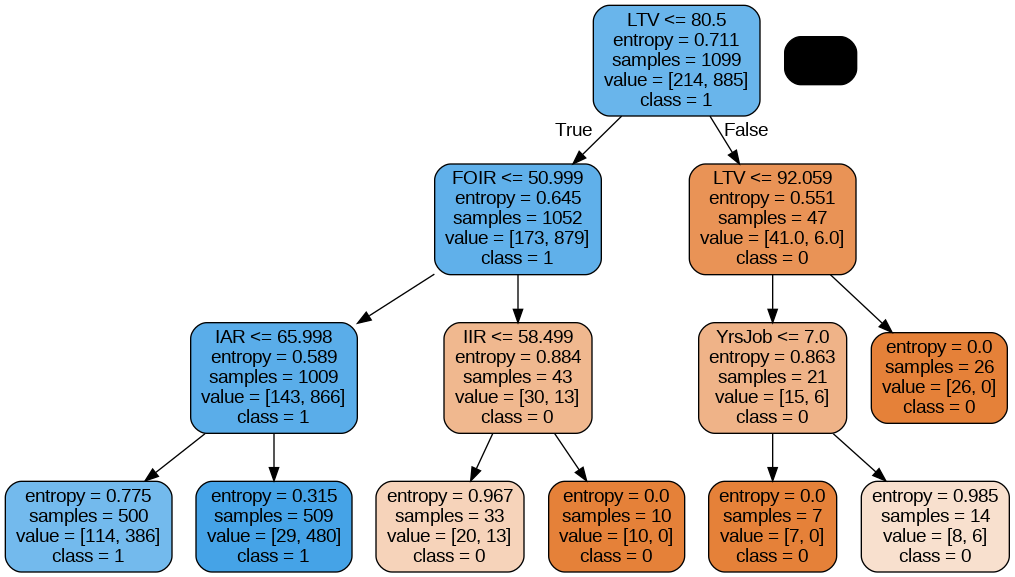

In [ ]:
### from textwrap import fill
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
### from sklearn import tree
from IPython.display import Image

dot_data = export_graphviz(clf,out_file=None,feature_names=Col,filled=True,rounded=True,class_names=['0','1'])

graph = graph_from_dot_data(dot_data)
graph.write_png('tree.png')
Image(graph.create_png())

### Confusion Matrix

Text(0.5, 23.52222222222222, 'Predicted label')

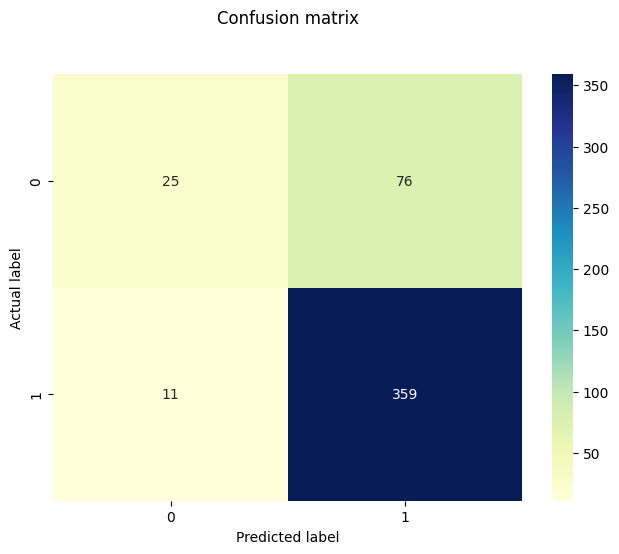

In [ ]:
cnf_matix= metrics.confusion_matrix(y_test,y_pred)
sns.heatmap(pd.DataFrame(cnf_matix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

### Hyperparameter Tunning ##Step 1

In [ ]:
parameters={
    "max_depth":[1,2,3,4,5,6,7,8,9,10,11,12],
    "criterion":["gini","entropy"]
}

In [ ]:
clf1=DecisionTreeClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(clf1,param_grid=parameters,cv=10,scoring='accuracy')

In [ ]:
grid.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]},
             scoring='accuracy')

In [ ]:
grid.best_score_

np.float64(0.8453628023352794)

In [ ]:
grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=2)

In [ ]:
feat_dict={}
for col, val in sorted(zip(x_train.columns,model.feature_importances_),
                           key=lambda x:x[1],reverse=True):
  feat_dict[col]=val

In [ ]:
feat_df = pd.DataFrame.from_dict(feat_dict,orient='index',columns=['Importance'])
feat_df

,Importance
LTV,0.452484
FOIR,0.246157
IAR,0.245945
IIR,0.032393
YrsJob,0.023020
Marital_Status,0.000000
OldEmi_d,0.000000
BankSave_d,0.000000
Age,0.000000
YrsAdd,0.000000


from matplotlib import pyplot as plt
feat_df['Importance'].plot(kind='hist', bins=20, title='Importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
feat_df['Importance'].plot(kind='line', figsize=(8, 4), title='Importance')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
Housing['Decision'].value_counts()

,count
Decision,
1,1255
0,315


### Class Imbalance Problem (SMOTE Method)

In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
sm= SMOTE(random_state=11)
x_res,y_res=sm.fit_resample(x_train,y_train)

In [ ]:
print(pd.Series(y_res).value_counts())
print(pd.Series(y_train).value_counts())

Decision
1    885
0    885
Name: count, dtype: int64
Decision
1    885
0    214
Name: count, dtype: int64


In [ ]:
clf2 = DecisionTreeClassifier (criterion='entropy',max_depth=2)
model2 = clf2.fit(x_res,y_res)
y_pred2 = model2.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
cm= confusion_matrix(y_test,y_pred2)
cm_df = pd.DataFrame(cm,columns=['Predicted 0','Predicted 1'],index=['Actual 0','Actual 1'])
cm_df

,Predicted 0,Predicted 1
Actual 0,78,23
Actual 1,229,141


In [ ]:
print(classification_report(y_test,y_pred2,digits=2))

              precision    recall  f1-score   support

           0       0.25      0.77      0.38       101
           1       0.86      0.38      0.53       370

    accuracy                           0.46       471
   macro avg       0.56      0.58      0.46       471
weighted avg       0.73      0.46      0.50       471

